# Global A–E Condition Profile — Same Design as the Previous Global Figure

This notebook keeps the **same global design style** as the previous coefficient/effect-profile figure:

- **3 side-by-side panels**: CTA, Headline, Product
- **8 metrics** on the y-axis
- **points + horizontal confidence intervals**
- clean modern styling
- same overall visual language

## What changes
Unlike the previous version, this one shows **all five conditions A, B, C, D, E equally**.

So it is still a **global overview figure**, but now:
- A is not only a reference
- C is not specially privileged
- all five conditions are plotted with the same visual weight

## Statistical summary shown
For each AOI × metric:
- complete matched images are used
- the five condition means are **standardized within that AOI × metric**
- horizontal intervals are **paired-bootstrap 95% CIs**
- an open ring marks the **best condition** according to the direction rule you define

This gives you a true **global A–E profile** in the **same design family** as the previous global figure.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"

AOIS = ["CTA", "Headline", "Product"]
CONDITIONS = ["A", "B", "C", "D", "E"]

METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

# Used only to identify the best condition.
BETTER_DIRECTION = {
    "VAI (%)": "max",
    "TTFF (s)": "min",
    "Time spent (s)": "max",
    "Fixations": "max",
    "Fix. duration (s)": "min",
    "FFD (s)": "min",
    "K-coefficient": "max",
    "Revisits": "max",
}

N_BOOTSTRAP = 5000
RANDOM_SEED = 42

OUTPUT_PDF = "GLOBAL_A_to_E_same_global_design.pdf"
OUTPUT_PNG = "GLOBAL_A_to_E_same_global_design.png"


## 2. Load data

In [3]:
if not Path(LONG_CSV).exists():
    raise FileNotFoundError(f"Could not find {LONG_CSV}")

df = pd.read_csv(LONG_CSV)
df.columns = [str(c).replace("**", "").strip() for c in df.columns]

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

print("Rows:", len(df))
print("AOIs:", sorted(df["AOI"].unique()))
print("Metrics:", sorted(df["metric"].unique()))


Rows: 2320
AOIs: ['CTA', 'Headline', 'Product']
Metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']


## 3. Build standardized condition means

In [4]:
def get_complete_pivot(aoi, metric):
    sub = df[
        (df["AOI"] == aoi)
        & (df["metric"] == metric)
        & (df["condition"].isin(CONDITIONS))
    ].copy()

    pivot = (
        sub.pivot(index="Img", columns="condition", values="value")
        .reindex(columns=CONDITIONS)
    )

    # Keep complete matched images only
    return pivot.dropna()


def standardize_matrix(values):
    """
    Standardize within one AOI × metric across all complete image-condition values.

    0 = pooled overall mean across A–E
    +1 = one pooled SD above that mean
    -1 = one pooled SD below that mean
    """
    arr = np.asarray(values, dtype=float)
    mu = np.nanmean(arr)
    sd = np.nanstd(arr, ddof=1)

    if not np.isfinite(sd) or sd == 0:
        sd = 1.0

    return (arr - mu) / sd, mu, sd


rows = []
seed_counter = 0

for aoi in AOIS:
    for metric in METRICS:
        pivot = get_complete_pivot(aoi, metric)

        if len(pivot) < 3:
            continue

        zmat, raw_mu, raw_sd = standardize_matrix(
            pivot[CONDITIONS].values
        )

        zdf = pd.DataFrame(
            zmat,
            index=pivot.index,
            columns=CONDITIONS
        )

        rng = np.random.default_rng(RANDOM_SEED + seed_counter)
        seed_counter += 1

        # Paired bootstrap at the image level
        boot_idx = rng.integers(
            0,
            len(zdf),
            size=(N_BOOTSTRAP, len(zdf))
        )

        for cond in CONDITIONS:
            vals = zdf[cond].values
            mean_z = np.mean(vals)

            boot_means = vals[boot_idx].mean(axis=1)
            lo, hi = np.percentile(boot_means, [2.5, 97.5])

            rows.append({
                "AOI": aoi,
                "metric": metric,
                "condition": cond,
                "n": len(zdf),
                "mean_z": mean_z,
                "ci_lower": lo,
                "ci_upper": hi,
                "raw_mean": pivot[cond].mean(),
            })

profile = pd.DataFrame(rows)
profile.head()


,AOI,metric,condition,n,mean_z,ci_lower,ci_upper,raw_mean
0,CTA,VAI (%),A,17,-0.389036,-0.865358,0.095198,21.635294
1,CTA,VAI (%),B,17,-0.052144,-0.503699,0.421056,26.682353
2,CTA,VAI (%),C,17,0.468508,0.047962,0.866290,34.482353
3,CTA,VAI (%),D,17,-0.089053,-0.574376,0.404546,26.129412
4,CTA,VAI (%),E,17,0.061724,-0.343106,0.503915,28.388235


## 4. Best condition per AOI × metric

In [5]:
best_rows = []

for aoi in AOIS:
    for metric in METRICS:
        sub = profile[
            (profile["AOI"] == aoi)
            & (profile["metric"] == metric)
        ].copy()

        if sub.empty:
            continue

        direction = BETTER_DIRECTION.get(metric, "max")

        if direction == "min":
            idx = sub["raw_mean"].idxmin()
        else:
            idx = sub["raw_mean"].idxmax()

        best_rows.append({
            "AOI": aoi,
            "metric": metric,
            "best_condition": sub.loc[idx, "condition"],
        })

best_df = pd.DataFrame(best_rows)
best_df.head()


,AOI,metric,best_condition
0,CTA,VAI (%),C
1,CTA,TTFF (s),C
2,CTA,Time spent (s),E
3,CTA,Fixations,C
4,CTA,Fix. duration (s),D


## 5. Plot the global figure

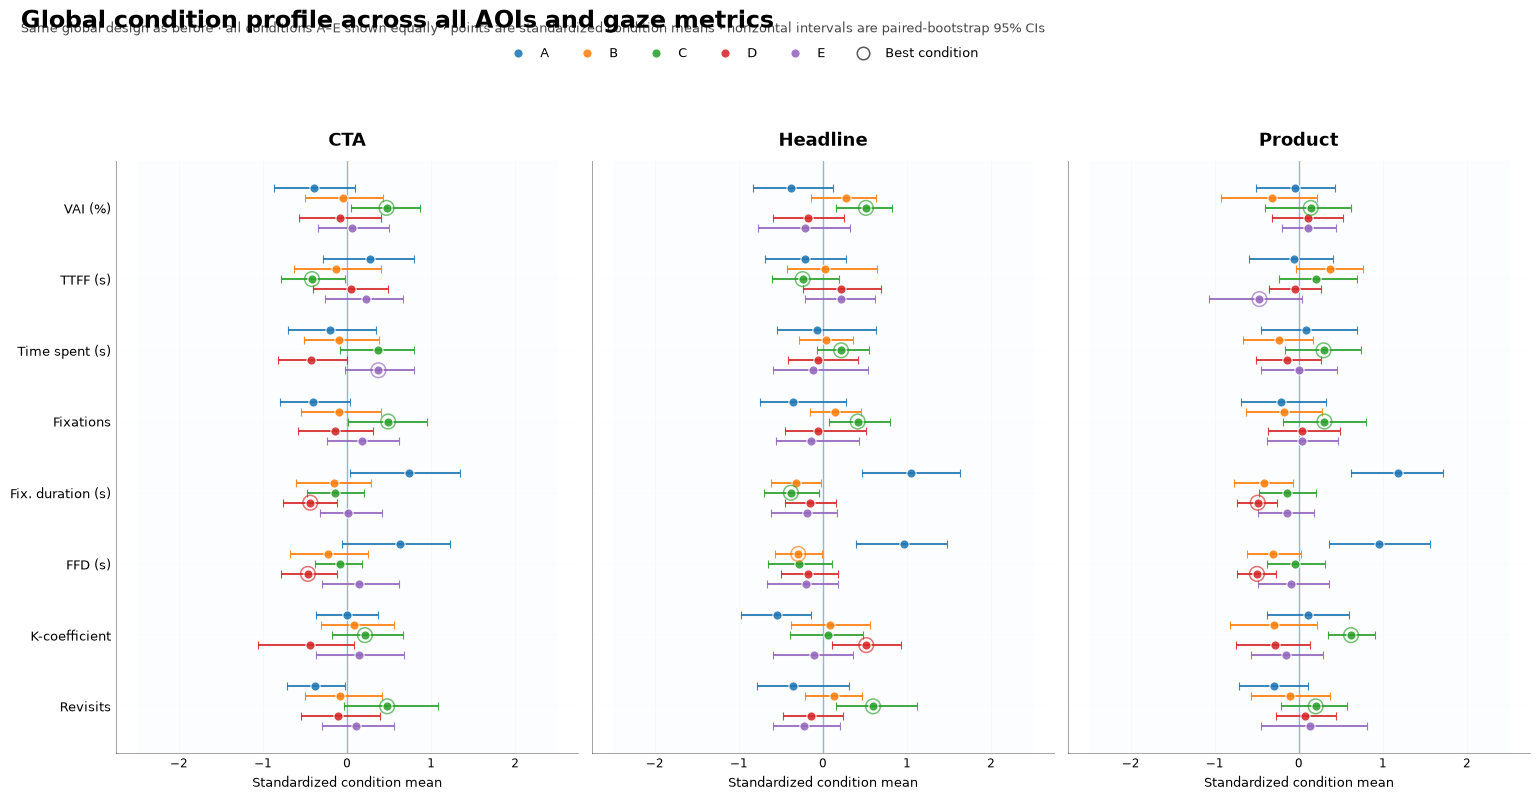

Saved: GLOBAL_A_to_E_same_global_design.pdf
Saved: GLOBAL_A_to_E_same_global_design.png


In [6]:
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 12.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.8,
    "ytick.labelsize": 9.2,
    "axes.linewidth": 0.75,
})

cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(cycle) < 5:
    cycle = [f"C{i}" for i in range(5)]

condition_colors = {
    cond: cycle[i]
    for i, cond in enumerate(CONDITIONS)
}

# Equal offsets for all A–E conditions
offsets = {
    "A": -0.28,
    "B": -0.14,
    "C": 0.00,
    "D": 0.14,
    "E": 0.28,
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16.2, 8.4),
    sharey=True
)

for ax, aoi in zip(axes, AOIS):
    sub = profile[profile["AOI"] == aoi].copy()

    # Same clean vertical reference line style
    ax.axvline(
        0,
        linewidth=1.0,
        alpha=0.50,
        zorder=1
    )

    # Same soft background feel
    xlim_guess = 2.5
    ax.axvspan(
        -xlim_guess,
        0,
        alpha=0.012,
        zorder=0
    )
    ax.axvspan(
        0,
        xlim_guess,
        alpha=0.012,
        zorder=0
    )

    for cond in CONDITIONS:
        csub = sub[sub["condition"] == cond]

        for i, metric in enumerate(METRICS):
            r = csub[csub["metric"] == metric]

            if r.empty:
                continue

            r = r.iloc[0]
            y = i + offsets[cond]

            left = r["mean_z"] - r["ci_lower"]
            right = r["ci_upper"] - r["mean_z"]

            ax.errorbar(
                r["mean_z"],
                y,
                xerr=np.array([[left], [right]]),
                fmt="o",
                markersize=6.6,
                capsize=3.0,
                elinewidth=1.45,
                color=condition_colors[cond],
                markeredgecolor="white",
                markeredgewidth=0.8,
                alpha=0.88,
                zorder=3
            )

    # Ring the best condition, same style idea as previous
    for i, metric in enumerate(METRICS):
        b = best_df[
            (best_df["AOI"] == aoi)
            & (best_df["metric"] == metric)
        ]

        if b.empty:
            continue

        best_cond = b.iloc[0]["best_condition"]

        r = sub[
            (sub["metric"] == metric)
            & (sub["condition"] == best_cond)
        ]

        if r.empty:
            continue

        r = r.iloc[0]
        y = i + offsets[best_cond]

        ax.scatter(
            r["mean_z"],
            y,
            s=112,
            facecolors="none",
            edgecolors=condition_colors[best_cond],
            linewidths=1.1,
            alpha=0.65,
            zorder=5
        )

    ax.set_title(
        aoi,
        fontsize=13,
        fontweight="bold",
        pad=11
    )

    ax.set_xlabel(
        "Standardized condition mean",
        fontsize=9.5
    )

    ax.grid(
        axis="x",
        linewidth=0.45,
        alpha=0.09
    )

    ax.grid(
        axis="y",
        linewidth=0.35,
        alpha=0.045
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)
    ax.tick_params(length=0)

axes[0].set_yticks(np.arange(len(METRICS)))
axes[0].set_yticklabels(METRICS, fontsize=9.2)

for ax in axes:
    ax.invert_yaxis()

handles = []
for cond in CONDITIONS:
    handles.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=6.6,
            markerfacecolor=condition_colors[cond],
            markeredgecolor="white",
            markeredgewidth=0.8,
            alpha=0.88,
            label=cond
        )
    )

handles.append(
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=9,
        markerfacecolor="none",
        markeredgecolor="0.35",
        markeredgewidth=1.1,
        label="Best condition"
    )
)

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=6,
    frameon=False,
    fontsize=9
)

fig.suptitle(
    "Global condition profile across all AOIs and gaze metrics",
    x=0.055,
    y=0.995,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.055,
    0.968,
    "Same global design as before · all conditions A–E shown equally · points are standardized condition means · horizontal intervals are paired-bootstrap 95% CIs",
    fontsize=9.5,
    alpha=0.72
)

fig.tight_layout(
    rect=[0.04, 0.05, 0.995, 0.91]
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUTPUT_PNG,
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", OUTPUT_PDF)
print("Saved:", OUTPUT_PNG)


## Output

```text
GLOBAL_A_to_E_same_global_design.pdf
GLOBAL_A_to_E_same_global_design.png
```

This is the corrected **global** version in the **same design family** as the previous global figure, but now with **A, B, C, D, and E all included equally**.
